In [68]:
# !pip uninstall -y torch torchvision torchaudio

In [69]:
# !pip install torch==2.0.0+cu117 torchvision==0.15.1+cu117 torchaudio==2.0.0+cu117 --extra-index-url https://download.pytorch.org/whl/cu117
# !pip install numpy pandas scikit-learn

In [70]:
# !pip install torchviz  

## Импорты 

In [71]:

import torch
import numpy as np
import pandas as pd
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from torch.nn.utils.rnn import pad_sequence
from torch.utils.data import DataLoader
from datetime import datetime, timedelta
from collections import Counter
from torchviz import make_dot
from itertools import chain
from torch.optim.lr_scheduler import LinearLR
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.optim import AdamW

## Загрузка датасетов

In [72]:
# Считываем датасеты

df_items = pd.read_csv('./dataset/KION_DATASET/data_en/items_en.csv')
df_users = pd.read_csv('./dataset/KION_DATASET/data_en/users_en.csv')
df_interactions = pd.read_csv('./dataset/KION_DATASET/interactions.csv')

In [73]:
df_interactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 1594786 entries, 0 to 1594785
Data columns (total 5 columns):
 #   Column         Non-Null Count    Dtype  
---  ------         --------------    -----  
 0   user_id        1594786 non-null  int64  
 1   item_id        1594786 non-null  int64  
 2   last_watch_dt  1594786 non-null  str    
 3   total_dur      1594786 non-null  int64  
 4   watched_pct    1594519 non-null  float64
dtypes: float64(1), int64(3), str(1)
memory usage: 60.8 MB


In [74]:
df_interactions = df_interactions[df_interactions['user_id'].isin(df_users['user_id'])].copy()
df_interactions = df_interactions[df_interactions['item_id'].isin(df_items['item_id'])].copy()
# Убираем интеракции пользователей и фильмов, которых нет в других df

In [75]:
df_users = df_users.drop("Unnamed: 0", axis=1)

In [76]:
df_items = df_items.drop("Unnamed: 0", axis=1)

## Обработка Интеракций

In [77]:
def check_date_with_formats(df, column_name, date_formats=None):
    """
    Проверка дат с учетом различных форматов
    """
    if date_formats is None:
        date_formats = ['%Y-%m-%d', '%d.%m.%Y', '%m/%d/%Y', '%Y-%m-%d %H:%M:%S']
    
    results = {}
    
    for date_format in date_formats:
        try:
            # Пробуем преобразовать с конкретным форматом
            converted = pd.to_datetime(df[column_name], format=date_format, errors='coerce')
            valid_count = converted.notna().sum()
            results[date_format] = valid_count
        except Exception:
            results[date_format] = 0
    
    # Находим лучший формат
    best_format = max(results.items(), key=lambda x: x[1])
    
    return {
        'best_format': best_format[0] if best_format[1] > 0 else None,
        'valid_count_with_best_format': best_format[1],
        'all_results': results
    }

def convert_to_datetime(series):
    result = pd.Series(index=series.index, dtype='object')
    idx1 = ['-' in i if i is not None else True  for i in series] # Ищет формат даты через "-" и None
    idx2 = [not i for i in idx1] # Делает замену True на False и False на True
    result[idx1] = pd.to_datetime(series[idx1], format='%Y-%m-%d')
    result[idx2] = pd.to_datetime(series[idx2], format='%d %m %Y')
    
    return result

In [78]:
df_inter_for_ds = df_interactions.drop(['total_dur'], axis=1, inplace=False).copy()

format_check = check_date_with_formats(df_inter_for_ds, 'last_watch_dt')
print("Результаты проверки форматов:")
for key, value in format_check.items():
    print(f"{key}: {value}")
     

print(df_inter_for_ds["item_id"].count())


df_inter_for_ds.loc[:, "date_w"] = convert_to_datetime (df_inter_for_ds["last_watch_dt"])
# Зачищаем даты 

Результаты проверки форматов:
best_format: %Y-%m-%d
valid_count_with_best_format: 1288996
all_results: {'%Y-%m-%d': np.int64(1288996), '%d.%m.%Y': np.int64(0), '%m/%d/%Y': np.int64(0), '%Y-%m-%d %H:%M:%S': np.int64(0)}
1288996


In [79]:
# делим на трейн и тест(валидация)
df_inter_for_ds.sort_values(by = "date_w",  ascending=False)
df_inter_for_ds.drop(columns=["last_watch_dt"],inplace=True)

days = 21
last_date = df_inter_for_ds["date_w"].max()

df_interactions_train = df_inter_for_ds[df_inter_for_ds["date_w"] < last_date - timedelta(days=days)].copy()

df_interactions_test = df_inter_for_ds[df_inter_for_ds["date_w"] >= last_date - timedelta(days=days)].copy()

In [80]:
# Кодируем категориальные признаки (но можно их закодировать прямо при построении датасета)
le_age = LabelEncoder()
le_inc = LabelEncoder()
le_sex = LabelEncoder()
df_users["age_en"] = le_age.fit_transform(df_users["age"])
df_users["income_en"] = le_inc.fit_transform(df_users["income"])
df_users["sex_en"] = le_inc.fit_transform(df_users["sex"])
df_users.head()

,user_id,age,income,sex,kids_flg,age_en,income_en,sex_en
0,973171,age_25_34,income_60_90,M,1,1,4,1
1,962099,age_18_24,income_20_40,M,0,0,2,1
2,1047345,age_45_54,income_40_60,F,0,3,3,0
3,721985,age_45_54,income_20_40,F,0,3,2,0
4,704055,age_35_44,income_60_90,F,0,2,4,0


In [81]:
def check_nan (df):
    # Проверка, есть ли вообще NaN значения в DataFrame
    has_any_nans = df.isna().any().any()
    print(f"Есть ли NaN в DataFrame: {has_any_nans}")

    # Столбцы, содержащие хотя бы один NaN
    columns_with_nans = df.columns[df.isna().any()].tolist()
    print(f"Столбцы с NaN: {columns_with_nans}")

    # Количество не-NaN значений
    non_nan_count = df.count()  # По столбцам
    print("Не-NaN значений по столбцам:")
    print(non_nan_count)
    

In [82]:
check_nan (df_interactions_train)

# Удаляем все строки, где есть хотя бы один NaN
df_inter_for_ds_cleaned = df_interactions_train.dropna()

check_nan (df_inter_for_ds_cleaned)

Есть ли NaN в DataFrame: True
Столбцы с NaN: ['watched_pct']
Не-NaN значений по столбцам:
user_id        994764
item_id        994764
watched_pct    994556
date_w         994764
dtype: int64
Есть ли NaN в DataFrame: False
Столбцы с NaN: []
Не-NaN значений по столбцам:
user_id        994556
item_id        994556
watched_pct    994556
date_w         994556
dtype: int64


In [83]:
check_nan (df_interactions_test)

# Удаляем все строки, где есть хотя бы один NaN
df_inter_for_test_cleaned = df_interactions_test.dropna()

check_nan (df_inter_for_test_cleaned)

Есть ли NaN в DataFrame: True
Столбцы с NaN: ['watched_pct']
Не-NaN значений по столбцам:
user_id        294232
item_id        294232
watched_pct    294230
date_w         294232
dtype: int64
Есть ли NaN в DataFrame: False
Столбцы с NaN: []
Не-NaN значений по столбцам:
user_id        294230
item_id        294230
watched_pct    294230
date_w         294230
dtype: int64


## Обработка фильмов

In [84]:
def split_and_clean(text):
    if pd.isna(text):
        return []
    return [t.strip().lower() for t in text.split(',') if t.strip()]

df_items['genres_list'] = df_items['genres'].apply(split_and_clean)
df_items['keywords_list'] = df_items['keywords'].apply(split_and_clean)

In [85]:

def build_vocab(list_column, min_freq=5):
    counter = Counter()
    
    for tokens in list_column:
        counter.update(tokens)

    vocab = {"<PAD>": 0, "<UNK>": 1}

    idx = 2
    for token, freq in counter.items():
        if freq >= min_freq:
            vocab[token] = idx
            idx += 1

    return vocab

def tokens_to_indices(tokens, vocab):
    return [vocab[t] for t in tokens if t in vocab]


genres_vocab = build_vocab(df_items['genres_list'], min_freq=1)
keywords_vocab = build_vocab(df_items['keywords_list'], min_freq=5)

print(len(genres_vocab), len(keywords_vocab))

158 5845


In [86]:
import numpy as np
from collections import Counter

# Функция для вычисления IDF
def compute_idf(vocab, token_lists):
    """
    vocab: dict {token: idx}
    token_lists: список списков токенов для каждого документа
    Возвращает dict {token: idf}
    """
    n_docs = len(token_lists)
    doc_freq = Counter()
    for tokens in token_lists:
        unique_tokens = set(tokens)
        doc_freq.update(unique_tokens)
    
    idf = {}
    for token, idx in vocab.items():
        if token in ['<PAD>', '<UNK>']:
            idf[token] = 0.0
        else:
            # Сглаженная IDF
            idf[token] = np.log((n_docs + 1) / (doc_freq[token] + 1)) + 1
    return idf

def build_weight_tensor(tokens_idx, idx_to_token, idf_dict, max_len):
    # Обрезаем список до max_len
    tokens_idx = tokens_idx[:max_len]
    weights = []
    for idx in tokens_idx:
        if idx == 0:  # PAD токен
            weight = 0.0
        else:
            token = idx_to_token[idx]
            weight = idf_dict.get(token, 0.0)
        weights.append(weight)
    # Паддинг до max_len
    if len(weights) < max_len:
        weights += [0.0] * (max_len - len(weights))
    return torch.tensor(weights, dtype=torch.float32)

In [87]:

df_items['genres_idx'] = df_items['genres_list'].apply(
    lambda x: tokens_to_indices(x, genres_vocab)
)

df_items['keywords_idx'] = df_items['keywords_list'].apply(
    lambda x: tokens_to_indices(x, keywords_vocab)
)

In [88]:
MAX_GENRES    = 9
MAX_KEYWORDS  = 200

# Вычисляем IDF для жанров и ключевых слов
genres_idf = compute_idf(genres_vocab, df_items['genres_list'])
keywords_idf = compute_idf(keywords_vocab, df_items['keywords_list'])

# Обратные словари для преобразования индекса в токен
idx_to_genre = {idx: token for token, idx in genres_vocab.items()}
idx_to_keyword = {idx: token for token, idx in keywords_vocab.items()}


# Для жанров используем MAX_GENRES
genres_weights = []
for idx_list in df_items['genres_idx']:
    w = build_weight_tensor(idx_list, idx_to_genre, genres_idf, MAX_GENRES)  # <-- MAX_GENRES, не MAX_KEYWORDS
    genres_weights.append(w)
genres_weights = torch.stack(genres_weights)  # (N, MAX_GENRES)

# Для ключевых слов используем MAX_KEYWORDS
keywords_weights = []
for idx_list in df_items['keywords_idx']:
    w = build_weight_tensor(idx_list, idx_to_keyword, keywords_idf, MAX_KEYWORDS)
    keywords_weights.append(w)
keywords_weights = torch.stack(keywords_weights)  # (N, MAX_KEYWORDS)

In [89]:


def pad_sequences(sequences, max_len):
    sequences = [torch.tensor(seq[:max_len]) for seq in sequences]
    return pad_sequence(sequences, batch_first=True, padding_value=0)

# MAX_GENRES = 5
# MAX_KEYWORDS = 20

genres_padded = pad_sequences(df_items['genres_idx'], MAX_GENRES)
keywords_padded = pad_sequences(df_items['keywords_idx'], MAX_KEYWORDS)

In [90]:
# genres_padded.shape     # (num_items, MAX_GENRES)
# keywords_padded.shape   # (num_items, MAX_KEYWORDS)

In [91]:
EMB_DIM = 64

# genres_emb_layer = nn.Embedding(
#     num_embeddings=len(genres_vocab) + 1,
#     embedding_dim=EMB_DIM,
#     padding_idx=0
# )

# keywords_emb_layer = nn.Embedding(
#     num_embeddings=len(keywords_vocab) + 1,
#     embedding_dim=EMB_DIM,
#     padding_idx=0
# )

genres_emb_layer = nn.Embedding(
    num_embeddings=len(genres_vocab)+1,
    embedding_dim=EMB_DIM,
    padding_idx=0
)

keywords_emb_layer = nn.Embedding(
    num_embeddings=len(keywords_vocab)+1,
    embedding_dim=EMB_DIM,
    padding_idx=0
)

In [92]:
genres_padded.shape

torch.Size([15963, 9])

In [93]:
genres_emb = genres_emb_layer(genres_padded)       # (N, G, D)
keywords_emb = keywords_emb_layer(keywords_padded) # (N, K, D)

In [94]:
# def masked_mean(embeddings, mask):
#     mask = mask.unsqueeze(-1)  # (N, L, 1)
#     summed = (embeddings * mask).sum(dim=1)
#     count = mask.sum(dim=1).clamp(min=1)
#     return summed / count

# genres_mask = (genres_padded != 0).float()
# keywords_mask = (keywords_padded != 0).float()

# genres_vec = masked_mean(genres_emb, genres_mask)
# keywords_vec = masked_mean(keywords_emb, keywords_mask)

In [95]:
print(f"genres_emb shape: {genres_emb.shape}")
print(f"genres_weights shape: {genres_weights.shape}")

genres_emb shape: torch.Size([15963, 9, 64])
genres_weights shape: torch.Size([15963, 9])


In [96]:
def weighted_mean(embeddings, weights):
    """
    embeddings: (N, L, D)
    weights: (N, L) — веса для каждого токена
    """
    weights = weights.unsqueeze(-1)  # (N, L, 1)
    summed = (embeddings * weights).sum(dim=1)
    count = weights.sum(dim=1).clamp(min=1)
    return summed / count

genres_vec = weighted_mean(genres_emb, genres_weights)       # (N, D)
keywords_vec = weighted_mean(keywords_emb, keywords_weights) # (N, D)

In [97]:
item_embedding = torch.cat([
    genres_vec,
    keywords_vec
], dim=1)  # (N, 2D)

In [98]:
item_id = 354
item_embedding[item_id]

tensor([-0.5219, -0.4015, -0.9826,  0.3554, -0.2675,  0.1629, -0.0726,  0.1732,
        -0.6903, -0.4408, -0.1863,  0.0192, -0.0022,  0.0885,  0.0076,  0.4347,
        -0.1629,  0.7543,  0.0081, -0.2930,  0.3917,  0.6888, -0.9046,  0.4505,
        -1.8451, -0.3926,  0.7822,  0.8410, -0.9089,  1.0846, -0.5772,  0.3072,
        -0.9062, -0.1726,  0.8366,  0.3473,  0.5690, -0.0734,  0.4529,  0.4189,
         0.2404, -0.6846, -0.3676,  1.0130,  0.5559, -0.8666,  0.9320,  0.0973,
        -0.0114,  0.9990, -0.8065, -1.6480, -0.1133,  0.3522,  0.2104,  1.0491,
         0.2495, -0.4715,  0.0837,  0.1537, -0.5241, -0.2391,  0.4958,  0.2407,
        -0.1826,  0.4540, -0.6311,  0.5400, -0.7194, -0.2259,  0.1145,  1.3762,
         0.4317, -0.1872,  0.4016,  0.0905,  0.2666, -0.0836, -0.1574,  0.3158,
         0.1700,  0.3085, -0.2862,  0.0300,  1.0816, -0.3149, -0.4480, -0.2729,
         0.8394, -0.4079, -1.1127, -0.1477,  1.1141,  0.0488,  0.1724, -0.4869,
        -0.0914, -0.2671, -0.5222, -0.31

In [99]:
def items_to_embeddings(item_ids, item_embedding):
    return item_embedding[item_ids]

def create_samples(seq):
    seq = list(seq)
    
    samples = []
    
    for i in range(1, len(seq)):
        input_seq = seq[max(0, i-MAX_LEN):i]
        
        input_seq = [int(x) for x in input_seq]
        target = int(seq[i])
        
        samples.append((input_seq, target))
    
    return samples


MAX_LEN = 30

df_inter = df_inter_for_ds_cleaned.sort_values(['user_id', 'date_w'])
user_sequences = df_inter.groupby('user_id')['item_id'].apply(list)

test_df_inter = df_inter_for_test_cleaned.sort_values(['user_id', 'date_w'])
test_user_sequences = test_df_inter.groupby('user_id')['item_id'].apply(list)

In [100]:
unique_items = df_items['item_id'].unique()
item2idx = {item_id: i+1 for i, item_id in enumerate(unique_items)}  # сдвиг на 1
idx2item = {i+1: item_id for i, item_id in enumerate(unique_items)}
num_items = len(unique_items) + 1

user_sequences_idx = user_sequences.apply(
    lambda seq: [item2idx[i] for i in seq if i in item2idx]
)
test_user_sequences_idx = test_user_sequences.apply(
    lambda seq: [item2idx[i] for i in seq if i in item2idx]
)

In [101]:

def pad_seq(seq, max_len):
    seq = [int(x) for x in seq]  
    
    seq = seq[-max_len:]
    pad_len = max_len - len(seq)
    
    return [0]*pad_len + seq

## Примешиваем данные о пользователе 

In [102]:
user2idx = {u: i for i, u in enumerate(df_users['user_id'].values)}
idx2user = {i: u for u, i in user2idx.items()}

In [103]:
user_features = df_users.set_index('user_id')[[
    'age_en', 'income_en', 'sex_en', 'kids_flg'
]]

# переведём в тензоры
age_tensor = torch.tensor(user_features['age_en'].values, dtype=torch.long)
income_tensor = torch.tensor(user_features['income_en'].values, dtype=torch.long)
sex_tensor = torch.tensor(user_features['sex_en'].values, dtype=torch.long)
kids_tensor = torch.tensor(user_features['kids_flg'].values, dtype=torch.float32)

In [104]:
all_samples = []
for user_id, seq in user_sequences_idx.items():
    if len(seq) < 2:
        continue
    samples = create_samples(seq)
    all_samples.extend([(s[0], s[1], user_id) for s in samples])

In [105]:
test_all_samples = []
for user_id, seq in test_user_sequences_idx.items():
    if len(seq) < 2:
        continue
    samples = create_samples(seq)
    test_all_samples.extend([(s[0], s[1], user_id) for s in samples])

In [106]:
test_all_samples

[([13695], 14959, 56),
 ([6690], 768, 75),
 ([768], 1883, 120),
 ([4731], 3635, 164),
 ([4731, 3635], 392, 164),
 ([4731, 3635, 392], 11998, 164),
 ([11434], 3338, 170),
 ([1883], 10605, 172),
 ([6690], 203, 181),
 ([8855], 13679, 189),
 ([15959], 2557, 226),
 ([12862], 4431, 241),
 ([12862, 4431], 12036, 241),
 ([12862, 4431, 12036], 13596, 241),
 ([3980], 11959, 272),
 ([3343], 6816, 291),
 ([101], 6347, 299),
 ([768], 1883, 322),
 ([6502], 14603, 339),
 ([6502, 14603], 3440, 339),
 ([7824], 12939, 344),
 ([7824, 12939], 6673, 344),
 ([7824, 12939, 6673], 15439, 344),
 ([2391], 14821, 400),
 ([2391, 14821], 13694, 400),
 ([6347], 5501, 401),
 ([6347, 5501], 9659, 401),
 ([6347], 10605, 482),
 ([15234], 9930, 495),
 ([15234, 9930], 10088, 495),
 ([15234, 9930, 10088], 4104, 495),
 ([7735], 4018, 509),
 ([7735, 4018], 3153, 509),
 ([7043], 9048, 516),
 ([15235], 10501, 531),
 ([12544], 3876, 539),
 ([1548], 4271, 545),
 ([9930], 13830, 551),
 ([7022], 12068, 556),
 ([7022, 12068], 1883

## Компиляция датасета

In [107]:
class RecDataset(torch.utils.data.Dataset):
    def __init__(self, samples, max_len, user2idx):
        self.samples = samples
        self.max_len = max_len
        self.user2idx = user2idx

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        seq, target, user_id = self.samples[idx]
        
        if isinstance(seq, torch.Tensor):
            seq = seq.tolist()
        
        seq_padded = pad_seq(seq, self.max_len)
        seq_padded = torch.tensor(seq_padded, dtype=torch.long)
        
        target = torch.tensor(target, dtype=torch.long)
        
        mask = (seq_padded != 0).long()
        
        user_idx = self.user2idx[user_id]
        
        return {
            "seq": seq_padded,
            "target": target,
            "mask": mask,
            "user": torch.tensor(user_idx, dtype=torch.long)
        }

In [108]:
dataset = RecDataset(all_samples, MAX_LEN, user2idx)
test_dataset = RecDataset(test_all_samples, MAX_LEN, user2idx)

BATCH_SIZE = 1024

loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, 
                    num_workers=2,  # или больше, зависит от CPU
                    pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                    num_workers=2,  # или больше, зависит от CPU
                    pin_memory=True)

In [109]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# class RecTransformer(nn.Module):
#     def __init__(self, num_items, num_users, emb_dim, max_len):
#         super().__init__()
        
#         # item + position embeddings
#         self.item_emb = nn.Embedding(num_items, emb_dim, padding_idx=0)
#         self.pos_emb = nn.Embedding(max_len, emb_dim)
#         self.dropout = nn.Dropout(0.1)
#         self.layernorm = nn.LayerNorm(emb_dim)
        
#         # user embeddings
#         self.user_emb = nn.Embedding(num_users, emb_dim)
        
#         # categorical features
#         self.age_emb = nn.Embedding(10, 8)
#         self.income_emb = nn.Embedding(10, 8)
#         self.sex_emb = nn.Embedding(3, 4)
        
#         # transformer
#         encoder_layer = nn.TransformerEncoderLayer(
#             d_model=emb_dim,
#             nhead=2,
#             dropout=0.1,
#             batch_first=True
#         )
#         self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)

#         # final projection for additional features
#         self.fc_features = nn.Linear(8 + 8 + 4 + 1, emb_dim) 
#         # self.fc_features = nn.Linear(16 + 16 + 8 + 1, emb_dim)  # вход = 41, выход = emb_dim
        
#     def forward(self, seq, user_idx, age, income, sex, kids):
#         B, L = seq.shape
#         device = seq.device
        
#         # positions
#         pos = torch.arange(L, device=device).unsqueeze(0).expand(B, L)
        
#         # sequence embeddings
#         x = self.item_emb(seq) + self.pos_emb(pos)
#         x = self.transformer(x)
#         seq_vec = x[:, -1, :]  # [batch, emb_dim]
#         seq_vec = self.dropout(seq_vec)
#         seq_vec = self.layernorm(seq_vec)
        
#         # user embedding
#         user_vec = self.user_emb(user_idx)  # [batch, emb_dim]
#         user_vec = self.dropout(user_vec)
        
#         # categorical features
#         age_vec = self.age_emb(age).squeeze(1)        # [batch, 16]
#         income_vec = self.income_emb(income).squeeze(1)  # [batch, 16]
#         sex_vec = self.sex_emb(sex).squeeze(1)        # [batch, 8]
        
#         # numeric feature
#         kids = kids.float().unsqueeze(1) / (kids.max() + 1e-6)  # [batch, 1] scaled
        
#         # combine categorical + numeric into feature vector → project to emb_dim
#         features_vec = torch.cat([age_vec, income_vec, sex_vec, kids], dim=1)  # [batch, 16+16+8+1]
#         features_vec = self.fc_features(features_vec)  # [batch, emb_dim]
#         features_vec = F.relu(features_vec)
#         features_vec = self.dropout(features_vec)
        
#         # combine seq + user + features
#         seq_user_vec = seq_vec + user_vec + features_vec  # [batch, emb_dim]
        
#         # logits via dot product с item embeddings
#         item_emb_weight = self.item_emb.weight  # [num_items, emb_dim]
#         logits = torch.matmul(seq_user_vec, item_emb_weight.T)  # [batch, num_items]
        
#         return logits

In [110]:
class RecTransformer(nn.Module):
    def __init__(self, num_items, num_users, emb_dim, max_len):
        super().__init__()
        
        # item + position embeddings
        self.item_emb = nn.Embedding(num_items, emb_dim, padding_idx=0)
        self.pos_emb = nn.Embedding(max_len, emb_dim)
        self.dropout = nn.Dropout(0.1)
        self.layernorm = nn.LayerNorm(emb_dim)
        
        # user embeddings
        self.user_emb = nn.Embedding(num_users, emb_dim)
        
        # categorical features (уменьшенные)
        self.age_emb = nn.Embedding(10, 4)
        self.income_emb = nn.Embedding(10, 4)
        self.sex_emb = nn.Embedding(3, 2)
        
        # transformer (упрощенный)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=emb_dim,
            nhead=1,
            dropout=0.1,
            batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)

        # final projection for additional features
        self.fc_features = nn.Linear(4 + 4 + 2 + 1, emb_dim)
        
    def forward(self, seq, user_idx, age, income, sex, kids):
        B, L = seq.shape
        device = seq.device
        
        pos = torch.arange(L, device=device).unsqueeze(0).expand(B, L)
        x = self.item_emb(seq) + self.pos_emb(pos)
        x = self.transformer(x)
        seq_vec = self.dropout(self.layernorm(x[:, -1, :]))
        
        user_vec = self.dropout(self.user_emb(user_idx))
        
        age_vec = self.age_emb(age).squeeze(1)
        income_vec = self.income_emb(income).squeeze(1)
        sex_vec = self.sex_emb(sex).squeeze(1)
        kids = kids.float().unsqueeze(1) / (kids.max() + 1e-6)
        
        features_vec = torch.cat([age_vec, income_vec, sex_vec, kids], dim=1)
        features_vec = F.relu(self.dropout(self.fc_features(features_vec)))
        
        seq_user_vec = seq_vec + user_vec + features_vec
        seq_user_vec = F.normalize(seq_user_vec, p=2, dim=1) 
        # return seq_user_vec 
        logits = torch.matmul(seq_user_vec, self.item_emb.weight.T)
        return logits

In [111]:
import torch.nn.functional as F

def weighted_bce(logits, y_true, alpha=0.9):
    pos_weight = torch.tensor([alpha], device=logits.device)  # перенос на GPU
    return F.binary_cross_entropy_with_logits(logits, y_true, pos_weight=pos_weight)

class LabelSmoothingCrossEntropy(nn.Module):
    def __init__(self, smoothing=0.1, ignore_index=0):
        super().__init__()
        self.smoothing = smoothing
        self.ignore_index = ignore_index

    def forward(self, logits, target):
        n_classes = logits.size(-1)
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            true_dist = torch.zeros_like(log_probs)
            true_dist.fill_(self.smoothing / (n_classes - 1))
            true_dist.scatter_(1, target.unsqueeze(1), 1.0 - self.smoothing)
            # убираем вклад ignore_index
            if self.ignore_index is not None:
                mask = (target == self.ignore_index).unsqueeze(1)
                true_dist = torch.where(mask, torch.zeros_like(true_dist), true_dist)
        loss = torch.sum(-true_dist * log_probs, dim=-1)
        # усредняем только по не-игнорируемым элементам
        if self.ignore_index is not None:
            mask = (target != self.ignore_index).float()
            loss = (loss * mask).sum() / mask.sum().clamp(min=1)
        else:
            loss = loss.mean()
        return loss

In [112]:
model = RecTransformer(len(item2idx) + 1, len(user2idx), EMB_DIM, MAX_LEN)
criterion = LabelSmoothingCrossEntropy(smoothing=0.1, ignore_index=0)
# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
optimizer = AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)


# criterion = nn.CrossEntropyLoss(ignore_index=0)
# criterion = weighted_bce
# criterion = nn.MultiLabelSoftMarginLoss()  # или BCEWithLogitsLoss
# criterion = weighted_bce
# criterion = nn.MultiLabelSoftMarginLoss()  # или BCEWithLogitsLoss

/tmp/ipykernel_153424/3790478970.py:26: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.num_heads is odd
  self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=1)


In [113]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = model.to(device)
age_tensor = age_tensor.to(device)
income_tensor = income_tensor.to(device)
sex_tensor = sex_tensor.to(device)
kids_tensor = kids_tensor.to(device)

In [114]:
total_batches = len(loader)
EPOCHS = 30
patience = 5
no_improve = 0
best_val_loss = float('inf')


total_steps = len(loader) * EPOCHS  
warmup_steps = int(0.1 * total_steps)
# scheduler = LinearLR(optimizer, start_factor=0.1, end_factor=1.0, total_iters=warmup_steps)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS)

hystory = {}
hystory_val = {}
prev_val_loss = float('inf')

for epoch in range(1, EPOCHS + 1):
    model.train()
    tot_loss = 0.0
    hystory[epoch] = []
    hystory_val[epoch] = []
    
    for j, batch in enumerate(loader, 1):
        seq = batch['seq'].to(device)
        target = batch['target'].to(device)
        user_idx = batch['user'].long().to(device)

        age = age_tensor[user_idx]
        income = income_tensor[user_idx]
        sex = sex_tensor[user_idx]
        kids = kids_tensor[user_idx]

        logits = model(seq, user_idx, age, income, sex, kids)
        loss = criterion(logits, target)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        hystory[epoch].append(loss.item())

        tot_loss += loss.item()
        if j % 100 == 0:
            print(f"\rEpoch {epoch} Batch {j}/{len(loader)} Loss: {tot_loss/j:.4f}", end="")

    avg_train_loss = tot_loss / len(loader)

    # Validation
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in test_loader:
            seq = batch['seq'].to(device)
            target = batch['target'].to(device)
            user_idx = batch['user'].long().to(device)

            age = age_tensor[user_idx]
            income = income_tensor[user_idx]
            sex = sex_tensor[user_idx]
            kids = kids_tensor[user_idx]

            logits = model(seq, user_idx, age, income, sex, kids)
            loss_val = criterion(logits, target)
            hystory_val[epoch].append(loss_val.item())

            val_loss += loss_val.item()

    avg_val_loss = val_loss / len(test_loader)
    scheduler.step()
    print(f"\nEpoch {epoch}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}")


    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        no_improve = 0
        torch.save(model.state_dict(), 'best_model.pt')
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

Epoch 1 Batch 600/614 Loss: 8.6290
Epoch 1: Train Loss = 8.6133, Val Loss = 8.4404
Epoch 2 Batch 600/614 Loss: 7.8254
Epoch 2: Train Loss = 7.8242, Val Loss = 8.4009
Epoch 3 Batch 600/614 Loss: 7.7683
Epoch 3: Train Loss = 7.7684, Val Loss = 8.3896
Epoch 4 Batch 600/614 Loss: 7.7395
Epoch 4: Train Loss = 7.7392, Val Loss = 8.3874
Epoch 5 Batch 600/614 Loss: 7.7095
Epoch 5: Train Loss = 7.7095, Val Loss = 8.3841
Epoch 6 Batch 600/614 Loss: 7.6709
Epoch 6: Train Loss = 7.6701, Val Loss = 8.3790
Epoch 7 Batch 600/614 Loss: 7.6200
Epoch 7: Train Loss = 7.6198, Val Loss = 8.3774
Epoch 8 Batch 600/614 Loss: 7.5635
Epoch 8: Train Loss = 7.5635, Val Loss = 8.3725
Epoch 9 Batch 600/614 Loss: 7.5048
Epoch 9: Train Loss = 7.5050, Val Loss = 8.3766
Epoch 10 Batch 600/614 Loss: 7.4458
Epoch 10: Train Loss = 7.4454, Val Loss = 8.3703
Epoch 11 Batch 600/614 Loss: 7.3878
Epoch 11: Train Loss = 7.3879, Val Loss = 8.3742
Epoch 12 Batch 600/614 Loss: 7.3330
Epoch 12: Train Loss = 7.3325, Val Loss = 8.385

In [115]:
import matplotlib.pyplot as plt

def plot_training_history_separate(hystory_train, hystory_val, smooth=True, window=50):
    """
    Раздельные графики Training и Validation loss с логарифмической шкалой.
    
    hystory_train: dict(epoch -> list of batch losses)
    hystory_val: dict(epoch -> list of batch losses)
    smooth: bool, применять скользящее среднее
    window: int, размер окна скользящего среднего
    """
    
    def smooth_loss(loss_list, w):
        if len(loss_list) < w:
            return loss_list
        return [sum(loss_list[i:i+w])/w for i in range(len(loss_list)-w+1)]
    
    fig, axs = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    
    # ---------- Train ----------
    for epoch in hystory_train:
        y = hystory_train[epoch]
        if smooth:
            y = smooth_loss(y, window)
        axs[0].plot(range(len(y)), y, label=f'Epoch {epoch}')
    axs[0].set_yscale('log')
    axs[0].set_ylabel('Loss')
    axs[0].set_title('Training Loss per Batch (log scale)')
    axs[0].legend()
    axs[0].grid(True, which='both', ls='--')
    
    # ---------- Validation ----------
    for epoch in hystory_val:
        y = hystory_val[epoch]
        if smooth:
            y = smooth_loss(y, window)
        axs[1].plot(range(len(y)), y, '--', label=f'Epoch {epoch}')  # пунктир
    axs[1].set_yscale('log')
    axs[1].set_xlabel('Batch')
    axs[1].set_ylabel('Loss')
    axs[1].set_title('Validation Loss per Batch (log scale)')
    axs[1].legend()
    axs[1].grid(True, which='both', ls='--')
    
    plt.tight_layout()
    plt.show()

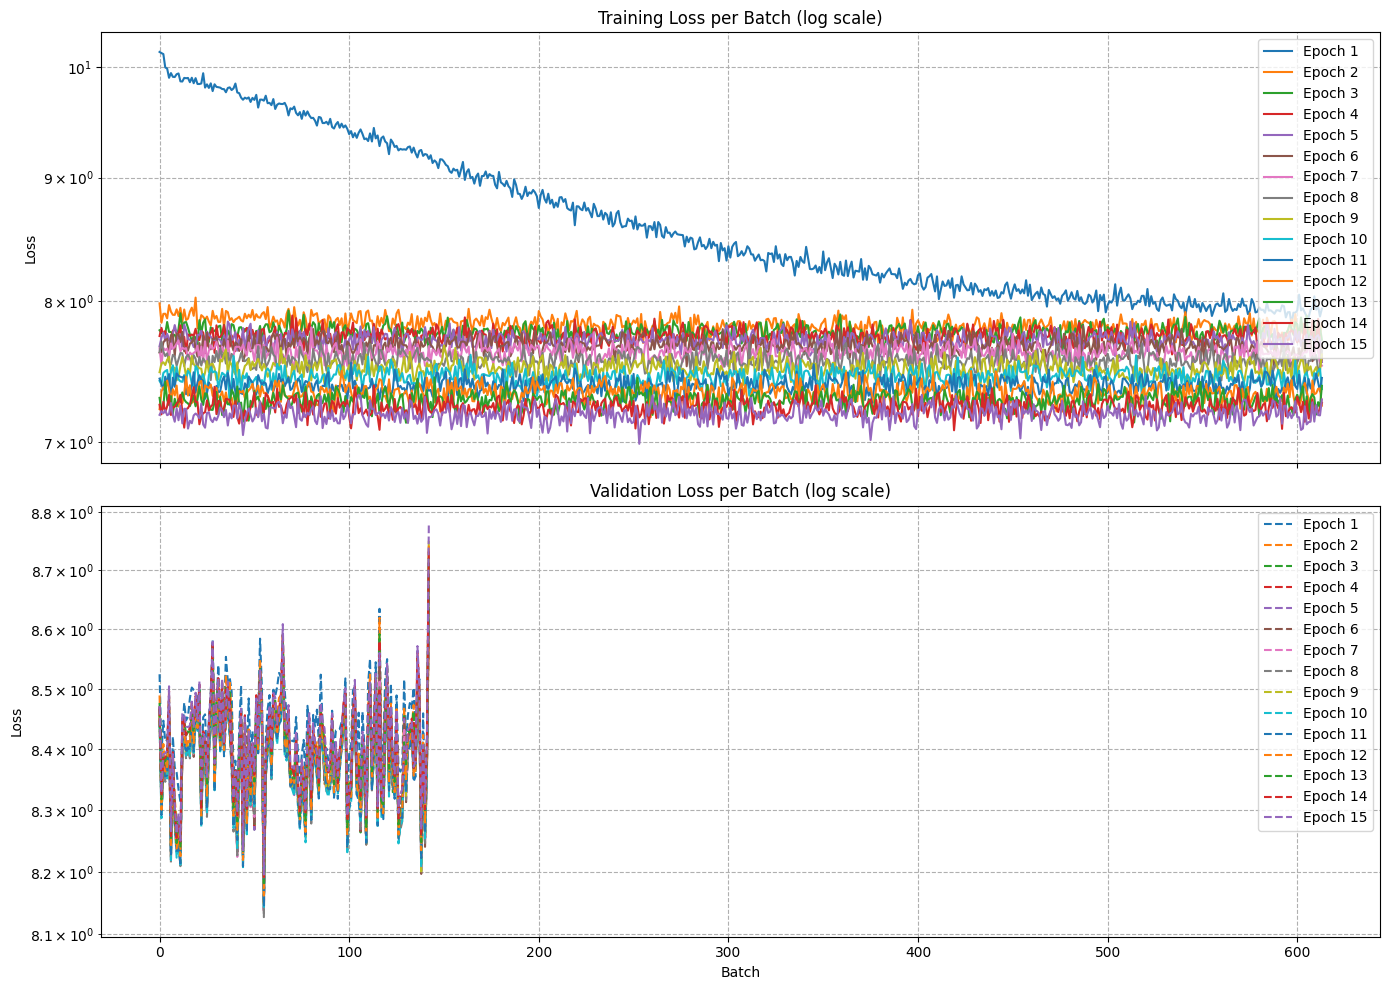

In [117]:
plot_training_history_separate(hystory, hystory_val, smooth=False )

In [118]:
model.eval()  # режим валидации
preds = []    # список для предсказаний
users = []    # список для user_id
actuals = []  # список для реальных товаров

with torch.no_grad():
    for batch in test_loader:
        seq = batch['seq'].to(device)
        target = batch['target'].to(device)
        user_idx = batch['user'].long().to(device)
        
        age = age_tensor[user_idx]
        income = income_tensor[user_idx]
        sex = sex_tensor[user_idx]
        kids = kids_tensor[user_idx]
        
        logits = model(seq, user_idx, age, income, sex, kids)
        
        # Предсказываем топ-N items для каждого пользователя (например, top 10)
        topk = 10
        top_items = torch.topk(logits, k=topk, dim=1).indices.cpu().tolist()
        
        preds.extend(top_items)
        users.extend(batch['user'].tolist())
        actuals.extend(target.cpu().tolist())

In [119]:
def metric_ratio(r, a, metric='precision'):
    """
    r: list of recommended items
    a: list of actual items
    metric: 'precision', 'recall', 'f1'
    """
    if not r:
        return 0.0
    common = len(set(r) & set(a))
    if metric == 'precision':
        return common / len(r)
    elif metric == 'recall':
        return common / len(a) if len(a) > 0 else 0.0
    elif metric == 'f1':
        p = common / len(r)
        r_val = common / len(a) if len(a) > 0 else 0.0
        return 2 * (p * r_val) / (p + r_val) if (p + r_val) > 0 else 0.0
    else:
        raise ValueError("Unsupported metric")

In [120]:

# flatten preds (список списков) в плоский список на пользователя
preds_flat = [list(chain.from_iterable(x)) if isinstance(x[0], list) else x for x in preds]

# actuals уже числа, оставляем как есть
actuals_flat = actuals

# создаем DataFrame
df_preds = pd.DataFrame({
    'user': users,
    'reco': preds_flat,
    'actual': actuals_flat
})

# группируем по пользователю
preds_by_user = df_preds.groupby('user')['reco'].agg(lambda x: list(chain.from_iterable(x)))
actual_by_user = df_preds.groupby('user')['actual'].agg(list)  # каждый user может иметь несколько actual

# создаем DataFrame для метрик
df_metrics = pd.DataFrame({
    'reco': preds_by_user,
    'actual': actual_by_user
}).dropna()

# Precision
precision_values = df_metrics.apply(lambda row: metric_ratio(row['reco'], row['actual'], 'precision'), axis=1)
precision = precision_values.mean()
print(f"Average Precision: {precision:.4f}")

# Recall
recall_values = df_metrics.apply(lambda row: metric_ratio(row['reco'], row['actual'], 'recall'), axis=1)
recall = recall_values.mean()
print(f"Average Recall: {recall:.4f}")

# F1
f1_values = df_metrics.apply(lambda row: metric_ratio(row['reco'], row['actual'], 'f1'), axis=1)
f1 = f1_values.mean()
print(f"Average F1: {f1:.4f}")

Average Precision: 0.0132
Average Recall: 0.1322
Average F1: 0.0240


In [121]:
import torch
import torch.nn.functional as F
import pandas as pd
from typing import Dict, List, Union

def compute_embedding_metrics(
    recs_by_user: Union[Dict, pd.Series],
    actual_by_user: Union[Dict, pd.Series],
    item_embeddings: torch.Tensor,
    top_k: int = 10,
    threshold: float = 0.7,
    device: str = "cpu"
) -> Dict[str, float]:
    """
    Вычисляет метрики качества рекомендаций на основе косинусного сходства эмбеддингов.

    Параметры:
    ----------
    recs_by_user : dict или pd.Series
        Ключ: идентификатор пользователя, значение: список рекомендованных ID фильмов.
        Если список длиннее top_k, он обрезается до top_k.
    actual_by_user : dict или pd.Series
        Ключ: идентификатор пользователя, значение: список реально просмотренных ID фильмов.
    item_embeddings : torch.Tensor
        Тензор эмбеддингов фильмов размерности (num_items, emb_dim).
    top_k : int, default=10
        Количество рекомендаций, учитываемых для каждого пользователя.
    threshold : float, default=0.7
        Порог косинусного сходства для hit rate.
    device : str, default="cpu"
        Устройство для вычислений ('cpu' или 'cuda').

    Возвращает:
    ----------
    dict
        Словарь с метриками:
        - 'avg_cosine_similarity' : среднее попарное косинусное сходство.
        - 'hit_rate' : доля пользователей, для которых есть рекомендация с сходством > threshold.
    """
    # Убедимся, что эмбеддинги на нужном устройстве и без градиентов
    item_embeddings = item_embeddings.to(device).detach()
    
    # Приведём входные данные к единому формату словаря
    if isinstance(recs_by_user, pd.Series):
        recs_by_user = recs_by_user.to_dict()
    if isinstance(actual_by_user, pd.Series):
        actual_by_user = actual_by_user.to_dict()
    
    # Получим общих пользователей
    common_users = set(recs_by_user.keys()) & set(actual_by_user.keys())
    if not common_users:
        print("Нет общих пользователей между рекомендациями и реальными просмотрами.")
        return {"avg_cosine_similarity": 0.0, "hit_rate": 0.0}
    
    total_cos_sim = 0.0
    total_max_cos_sim = 0.0
    total_hits = 0
    valid_users = 0
    
    for user in common_users:
        recs = recs_by_user[user][:top_k]      # обрезаем до top_k
        actual = actual_by_user[user]
        
        if not recs or not actual:
            continue
        
        # Извлекаем эмбеддинги
        rec_ids = torch.tensor(recs, device=device, dtype=torch.long)
        actual_ids = torch.tensor(actual, device=device, dtype=torch.long)
        
        # Эмбеддинги рекомендованных и реальных фильмов
        rec_embs = item_embeddings[rec_ids]       # (K, D)
        actual_embs = item_embeddings[actual_ids] # (M, D)
        
        # Вычисляем попарное косинусное сходство
        # rec_embs: (K, D), actual_embs: (M, D) -> similarity: (K, M)
        similarity = F.cosine_similarity(
            rec_embs.unsqueeze(1),   # (K, 1, D)
            actual_embs.unsqueeze(0), # (1, M, D)
            dim=2
        )  # (K, M)
        
        # Среднее сходство по всем парам
        avg_sim = similarity.mean().item()
        max_sim = similarity.max().item()
        total_max_cos_sim += max_sim
        total_cos_sim += avg_sim
        
        # Hit: есть ли пара с сходством > threshold
        if (similarity > threshold).any():
            total_hits += 1
        
        valid_users += 1
    
    if valid_users == 0:
        return {"avg_cosine_similarity": 0.0, "hit_rate": 0.0}
    
    
    avg_max_cos_sim = total_max_cos_sim / valid_users
    avg_cos_sim = total_cos_sim / valid_users
    hit_rate = total_hits / valid_users
    
    return {
        f"avg_max_cos_sim@{top_k}": avg_max_cos_sim,
        f"avg_cosine_similarity@{top_k}": avg_cos_sim,
        f"hit_rate@{top_k}_cos>{threshold}": hit_rate
    }

In [122]:
# Предположим, у вас есть DataFrame df_preds с колонками 'user', 'reco', 'actual'
# Где 'reco' — список рекомендованных ID, 'actual' — список реальных ID.

# Группируем
preds_by_user = df_preds.groupby('user')['reco'].agg(lambda x: list(chain.from_iterable(x)))
actual_by_user = df_preds.groupby('user')['actual'].agg(list)

# Вычисляем метрики
metrics = compute_embedding_metrics(
    recs_by_user=preds_by_user,
    actual_by_user=actual_by_user,
    item_embeddings=item_embedding,   # ваш тензор эмбеддингов фильмов
    top_k=10,
    threshold=0.7,
    device='cuda' if torch.cuda.is_available() else 'cpu'
)

print(metrics)

{'avg_max_cos_sim@10': 0.6131502775022609, 'avg_cosine_similarity@10': 0.08925963434445339, 'hit_rate@10_cos>0.7': 0.46818249172662463}


Поскольку реальных достижений модель не имеет, будем довольствоваться тем, что есть.  
Расмотрим дополнительные метрики. Все они отражают не буквальное "попадание" рекомендации в фактические просмотры пользователя, а схожесть эмбеддингов предложенных фильмов с эмбеддингами просмотренных.
    
**avg_cosine_similarity@10** — Это среднее косинусное сходство эмбедингов всех предложенных и просмотренных фильмов. Метрика принимает значение от -1 до 1. В нашем случае значение примерно равно 0.089, что говорит о том, что предложенные фильмы мало чем лучше случайных  
  
**hit_rate@10_cos>0.7** — Это доля пользователей, которые получили хотя бы одну рекомендацию со схожестью выше 0.7. В нашем случае - это ~0.468, что говорит о том, что около половины пользователей получили рекомендации в сооствествии с тем, что они по итогу посмортели, пусть и не фактически тот же фильм  
  
**avg_max_cos_sim@10** — Это среднее максимальное косинусное сходство. Указывает на среднее значение лучших предложений для каждого пользователя. Значение в 0.61 говорит об умении попадать в жанр/ключевые слова с относительно высокой точностью 

In [123]:
def show_user_recommendations(user_seq, pred_topk, target, df_movies, idx2item, top_history=10):
    """
    Выводит предыдущие фильмы пользователя, предсказанные и реальные (тест).
    
    user_seq: list или 1D tensor, последовательность просмотренных фильмов (индексы item2idx)
    pred_topk: list, top-N предсказанных фильмов (индексы item2idx)
    target: list, реальные фильмы для теста (индексы item2idx)
    df_movies: DataFrame с ['item_id', 'title', 'genres', 'keywords']
    idx2item: dict {index: original_item_id}
    top_history: сколько последних фильмов истории показывать
    """
    # Преобразуем индексы в оригинальные item_id
    history_ids = [idx2item[idx] for idx in user_seq[-top_history:] if idx != 0]
    pred_ids = [idx2item[idx] for idx in pred_topk if idx != 0]
    target_ids = [idx2item[idx] for idx in target if idx != 0]
    
    # предыдущие фильмы
    df_history = df_movies[df_movies['item_id'].isin(history_ids)][['title','genres','keywords']]
    print("=== История пользователя (последние {} фильмов) ===".format(top_history))
    display(df_history.reset_index(drop=True))
    
    # предсказанные фильмы
    df_pred = df_movies[df_movies['item_id'].isin(pred_ids)][['title','genres','keywords']]
    print("\n=== Предсказанные фильмы (Top-N) ===")
    display(df_pred.reset_index(drop=True))
    
    # реальные фильмы из теста
    df_test = df_movies[df_movies['item_id'].isin(target_ids)][['title','genres','keywords']]
    print("\n=== Реальные фильмы (тест) ===")
    display(df_test.reset_index(drop=True))

In [124]:
# пример для одного пользователя
user_idx = 57

# последовательность истории пользователя
user_seq = batch['seq'][0].cpu().tolist()  # первый элемент батча

# top-10 предсказанных
pred_topk = torch.topk(logits[0], k=10).indices.cpu().tolist()

# реальные фильмы из target
target_list = [target[0].item()]  # если target один фильм
# если несколько фильмов: target_list = target[0].cpu().tolist()

show_user_recommendations(user_seq, pred_topk, target_list, df_items, idx2item)

=== История пользователя (последние 10 фильмов) ===


,title,genres,keywords
0,X-Men,"action, science fiction","Mutant, comic book-based superhero, superman, ..."
1,Rage,"action, drama, thriller, crime","Rioting, carnage, murder, Car chase, Bank, Ban..."
2,[4k] Dracula,"foreign, horror, fantasy, melodrama","4k, Dracula, 1992, USA, vampires, werewolves, ..."
3,Ace Ventura: Finding Pets,"adventure, detective, comedy","Miami, Florida, dolphin, detective, human-anim..."
4,The Last Witch Hunter,"action, fantasy, adventure","New York, Witch, Rebellion, Witch Hunter, Engl..."
5,Spider-Man: Homecoming,"action, science fiction, adventure","Venice, Italy, Europe, Prague, Czech Republic,..."
6,Taxi 4,"action, foreign, crime, comedy","Taxi 4, 2007, France, bandits, gangsters, lose..."
7,[4k] Hancock,"drama, foreign, comics, science fiction, actio...","4k, Hancock, 2008, USA, love, losers, pursuits..."
8,[4k] Terminator: The Genesis,"science fiction, foreign, action, thrillers","4k, Terminator, Genesis, 2015, United States, ..."
9,John Wick 2,"action, thrillers, crime","Italy, pistol, roof, party, sequel, handshake,..."



=== Предсказанные фильмы (Top-N) ===


,title,genres,keywords
0,Captain Marvel,"action, science fiction","Superhero, based on the comic book, superheroi..."
1,Wheelbarrows 3,"animation, comedy","coach, continuation, travel, racing, CGI, anth..."
2,Ford vs. Ferrari,drama,"based on a novel or book, biography, sports, L..."
3,The Wrath of Man,"action, thriller","robbery, criminal authority, revenge, shooting..."
4,Venom,"popular, fiction, thrillers, action, horror","San Francisco, California, spaceship, anti-her..."
5,Monster Corporation,"animation, fantasy, adventure, comedy","Monster, Deception, Kidnapping, Baby, Villain,..."
6,The Little Mermaid,"musicals, cartoons, fantasy, melodramas","Sea, Firework, Prince, Kingdom, Daughter, Merm..."
7,Shrek,"animation, fantasy, adventure, comedy","Magic, liberation, ruler, prince, castle, fair..."
8,Guardians of the Galaxy - Part 2,"action, science fiction, adventure, comedy","sequels, superhero based on comics, space, 198..."
9,Code 8,"action, science fiction","Drug trafficking, dystopia, remake, relationsh..."



=== Реальные фильмы (тест) ===


,title,genres,keywords
0,28 Panfilov,"drama, historical, military","Germany, Hero, World War II, Russia, Nazis, So..."
